# Customer Segmentation using K-Means Clustering

We load the Mall Customers dataset from Kaggle and perform unsupervised learning to group customers based on purchasing behavior.

In [ ]:
from google.colab import files
import os

files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

Saving kaggle.json to kaggle.json
Kaggle API configured successfully!


In [ ]:
!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python

!unzip customer-segmentation-tutorial-in-python.zip

Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
100% 1.55k/1.55k [00:00<00:00, 4.51MB/s]

Archive:  customer-segmentation-tutorial-in-python.zip
  inflating: Mall_Customers.csv      


In [ ]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Preprocessing for Clustering

For K-Means clustering, we select numerical features and convert categorical variables into numeric form. We then prepare the dataset for clustering analysis.

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_cluster = df.drop("CustomerID", axis=1)

le = LabelEncoder()
df_cluster["Gender"] = le.fit_transform(df_cluster["Gender"])

df_cluster.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## Feature Selection

We select relevant features for clustering analysis.

In [ ]:
X = df_cluster

print("Final feature set shape:", X.shape)
X.head()

Final feature set shape: (200, 4)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## Elbow Method for Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of clusters (K) by plotting the Within-Cluster Sum of Squares (WCSS) for different values of K.

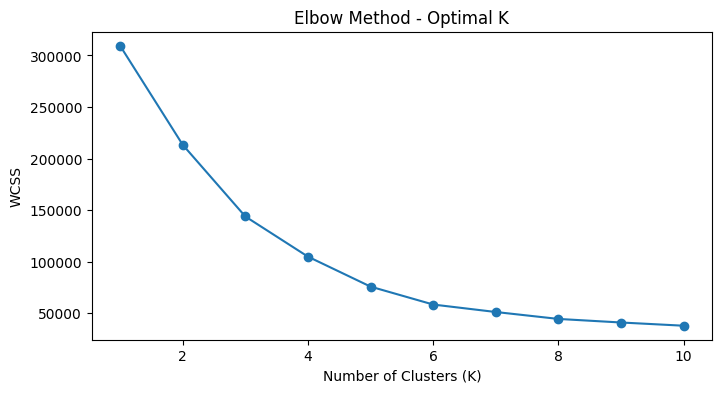

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method - Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

## K-Means Clustering Final Model

We apply K-Means clustering using the optimal number of clusters (K = 6) to segment customers based on their behavior.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

df_cluster["Cluster"] = clusters

df_cluster.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,5
1,1,21,15,81,2
2,0,20,16,6,5
3,0,23,16,77,2
4,0,31,17,40,5


## Dimensionality Reduction using PCA

We use Principal Component Analysis (PCA) to reduce the dataset from 4 dimensions to 2 dimensions for visualization of clusters.

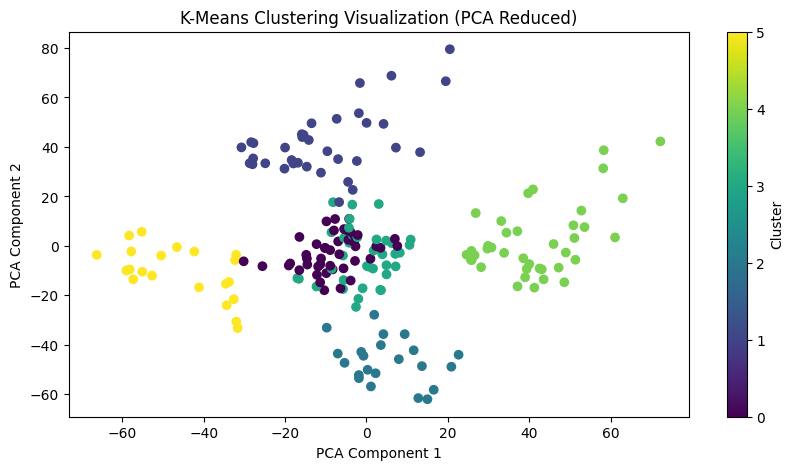

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,5))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')

plt.title("K-Means Clustering Visualization (PCA Reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

## Cluster Interpretation

We analyze the characteristics of each customer cluster based on age, income, and spending behavior.

In [ ]:
df_cluster.groupby("Cluster").mean()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.444444,56.155556,53.377778,49.088889
1,0.571429,41.685714,88.228571,17.285714
2,0.409091,25.272727,25.727273,79.363636
3,0.342105,27.000000,56.657895,49.131579
4,0.461538,32.692308,86.538462,82.128205
5,0.380952,44.142857,25.142857,19.523810


## Conclusion

K-Means clustering was applied to segment customers into 6 groups based on their demographic and spending behavior.

Key findings:
- Customers were successfully grouped into distinct clusters.
- PCA visualization shows clear separation between clusters.
- Each cluster represents a unique customer segment with different spending habits and income levels.